# WP4 Annex A, Level 4: the ore rule, checked basis piece by basis piece

Level 4 of the sediment-hosted recipe encodes the concept's core claim as a rule. An ore blanket forms where three conditions coincide: a basalt margin within a reach d, about 0 to 10 km; reduced facies present (Level 3); and a lineament-intersection factor that multiplies the occurrence probability. Where the rule fires, a stratabound lens is placed with thickness 2 to 30 m, grade 1 to 4% Cu and a lognormal tonnage with median of order tens of millions of tonnes. The annex marks every one of these numbers [CHECK]. It closes with *"Basis: Haynes's memoranda for the rule and its reach, and the analog deposits as known by 1975, the Zambian Copperbelt, White Pine, and the Kupferschiefer, for the blanket statistics."* Two pieces, taken one at a time:

- **Part A: Haynes's memoranda (rule and reach).** The memoranda are internal WMC papers, not in open file (`haynes_memoranda/NOT_FOUND.md`). In their place the folder holds what a t0 reader could have leaned on: the Mount Gunson reports WMC's own concept named, O'Driscoll's September 1974 lineament targets, and, as a cross-check only, the EL 190 first quarterly written after t0.
- **Part B: the analog blanket statistics as known by 1975.** USGS Professional Paper 820 (1973), copper chapter; four Economic Geology papers placed by hand (White 1942 on Mansfeld, Douglas 1955 on Roan Antelope, Love 1962 on the Kupferschiefer, Gillson 1963 reviewing Mendelsohn's 1961 Copperbelt volume); the Level 3 analog statements (Liege 1974, White and Wright 1954, Brown 1971); and the Mount Gunson grade and tonnage figures.

Each part ends with a verdict on its piece; Part C lays the Annex A Level 4 rows against what the folder can now cite. Only files in `wp4_prior_state/annexA_levels/level4_ore_rule/` are read. The information-state rule is one cutoff, t0 = 2 May 1975 (the EL 190 grant). Figures are drawn at final printed width and saved at 300 dpi to `03_results/wp4_prior/figures/` as `wp4_L4_<part><step>_*.png`.


In [1]:
# --- journal figure style ---------------------------------------------------
# Every text element has an explicit size; figures are drawn at final printed
# width so the point sizes below are the sizes that reach the page.
import matplotlib.pyplot as plt

FS_TICK, FS_LABEL, FS_LEGEND, FS_ANNOT, FS_PANEL = 8, 9, 8, 7, 9
COL1, COL15, COL2 = 3.5, 5.5, 7.2      # single / 1.5 / double column width (in)

plt.rcParams.update({
    # typeface
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size": FS_TICK,
    # text elements
    "axes.labelsize": FS_LABEL,
    "axes.titlesize": FS_PANEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "legend.title_fontsize": FS_LEGEND,
    "figure.titlesize": FS_LABEL,
    # axes furniture: thin frame, ticks inward on all four sides, minor ticks
    "axes.linewidth": 0.6,
    "axes.grid": False,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4, "ytick.minor.width": 0.4,
    "xtick.major.size": 3.0, "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8, "ytick.minor.size": 1.8,
    # marks
    "lines.linewidth": 1.0,
    "lines.markersize": 3.0,
    "legend.frameon": False,
    "legend.handlelength": 1.6,
    "legend.borderaxespad": 0.4,
    # output
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

def panel_labels(axes, labels=("(a)", "(b)")):
    """Bold (a)/(b) above the top-left corner of each axes."""
    for ax, lab in zip(axes, labels):
        ax.set_title(lab, loc="left", fontsize=FS_PANEL, fontweight="bold")

# --- batlow: Crameri's scientific colour map (Crameri et al. 2020, Nat. Commun.)
# 32 anchor points interpolated to 256 steps; reproduces the published map to
# within 1.4/255 per channel. Embedded so the notebook needs no extra package.
from matplotlib.colors import LinearSegmentedColormap
_BATLOW = [
    (0.0052, 0.0982, 0.3498), (0.0321, 0.1468, 0.3582), (0.0494, 0.1911, 0.3658), (0.0592, 0.2298, 0.3723),
    (0.0679, 0.2671, 0.3782), (0.0771, 0.2970, 0.3824), (0.0903, 0.3257, 0.3849), (0.1097, 0.3531, 0.3842),
    (0.1413, 0.3812, 0.3771), (0.1778, 0.4030, 0.3638), (0.2201, 0.4219, 0.3443), (0.2662, 0.4386, 0.3201),
    (0.3208, 0.4560, 0.2898), (0.3709, 0.4711, 0.2621), (0.4225, 0.4861, 0.2345), (0.4762, 0.5013, 0.2081),
    (0.5402, 0.5186, 0.1831), (0.6005, 0.5336, 0.1706), (0.6627, 0.5475, 0.1740), (0.7243, 0.5596, 0.1954),
    (0.7906, 0.5714, 0.2362), (0.8457, 0.5817, 0.2826), (0.8958, 0.5938, 0.3379), (0.9378, 0.6096, 0.4023),
    (0.9708, 0.6324, 0.4833), (0.9864, 0.6555, 0.5571), (0.9923, 0.6790, 0.6283), (0.9930, 0.7020, 0.6958),
    (0.9914, 0.7276, 0.7703), (0.9891, 0.7510, 0.8380), (0.9860, 0.7753, 0.9084), (0.9814, 0.8004, 0.9813),
]
BATLOW = LinearSegmentedColormap.from_list("batlow", _BATLOW, N=256)

import matplotlib.patheffects as _pe
HALO = [_pe.withStroke(linewidth=1.6, foreground="white")]   # keeps markers and
# labels legible where they sit on a filled colour field


## Data

All reads are relative paths into the Level 4 folder. `level4_blanket_statistics_pre_t0.csv` holds 46 transcribed statements (rows 1 to 26 from PP 820, 27 to 44 from the four Economic Geology papers, 45 and 46 from White and Wright 1954), each with its quote, PDF page and printed page. Rows of the Mount Gunson dossier are cited as G*n* and rows of the Level 3 analog table as "L3 row *n*". PP 820 quotes short tons; they are converted to tonnes (x 0.9072) where a figure mixes sources. The Australian reports and White (1942) say "tons" without a qualifier; they are used as stated, a difference of under 10% that is invisible on the logarithmic axes below. Every figure cites the rows it draws from, and the helper functions `R`, `G` and `D` check that each cited row holds the parameter the code expects.


In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from scipy import stats

L4 = Path("../../01_data/wp1_data/database/wp4_prior_state/annexA_levels/level4_ore_rule")
FIG = Path("../../03_results/wp4_prior/figures")
TAB = Path("../../03_results/wp4_prior")
assert L4.is_dir(), "run from 02_code/notebooks/"
FIG.mkdir(parents=True, exist_ok=True)
HM, AB = L4 / "haynes_memoranda", L4 / "analog_blanket_statistics"

T0 = pd.Timestamp("1975-05-02")                        # EL 190 grant: the one cutoff
PIECE_COL = {1: "#2a78d6", 2: "#eda100"}               # one colour per basis piece, as in Levels 1 to 3
GUNSON_COL = "#2e5e4e"                                 # Mount Gunson, the analog WMC named
ANNEX_GREY = "0.88"                                    # Annex A placeholder range, in every figure
ST = 0.9072                                            # short ton to tonne (PP 820 quotes short tons)

for sub in sorted(p for p in L4.rglob("*") if p.is_dir()):
    files = [p for p in sub.iterdir() if p.is_file()]
    print(f"{str(sub.relative_to(L4)):52s} {len(files):3d} files {sum(p.stat().st_size for p in files)/1e6:6.1f} MB")

BS = pd.read_csv(AB / "level4_blanket_statistics_pre_t0.csv")
MG = pd.read_csv(AB / "from_level3/mount_gunson_t0_dossier.csv")
DIM = pd.read_csv(AB / "from_level3/level3_analog_dimensions_pre_t0.csv")
OD = pd.read_csv(HM / "stand_ins/odriscoll_OD6iv_1974_blue_targets.csv")
EL = (HM / "stand_ins/el190_q1_concept_statement.md").read_text(encoding="utf-8")

def R(i, key):
    """row i of the Level 4 table, checked against the parameter it should hold"""
    r = BS.loc[BS.row == i].iloc[0]; assert key in r.parameter, (i, r.parameter); return r
def G(i, key):
    r = MG.loc[MG.row == i].iloc[0]; assert key in r.topic, (i, r.topic); return r
def D(i, key):
    r = DIM.loc[DIM.row == i].iloc[0]; assert key in r.parameter, (i, r.parameter); return r
num = lambda s: [float(x) for x in re.findall(r"\d+(?:\.\d+)?", str(s).replace(",", ""))]

print(f"\nLevel 4 table: {len(BS)} rows from {BS.source.nunique()} sources, all dated before t0: "
      f"{bool((BS.status_t0 == 'pre-t0').all())}")
print(f"Mount Gunson dossier: {len(MG)} rows; Level 3 analog statements: {len(DIM)}; O'Driscoll 1974 targets: {len(OD)}")
print("EL 190 concept statement dated after t0:", "2 May - 2 August, 1975" in EL)


analog_blanket_statistics                              2 files    0.0 MB
analog_blanket_statistics/from_level3                  2 files    0.0 MB
analog_blanket_statistics/from_level3/transcriptions  12 files    0.8 MB
analog_blanket_statistics/hand_placed                  4 files    1.1 MB
analog_blanket_statistics/hand_placed/transcriptions   4 files    0.2 MB
analog_blanket_statistics/usgs_pp820_1973              2 files    4.3 MB
haynes_memoranda                                       1 files    0.0 MB
haynes_memoranda/stand_ins                             3 files    0.0 MB

Level 4 table: 46 rows from 6 sources, all dated before t0: True
Mount Gunson dossier: 37 rows; Level 3 analog statements: 15; O'Driscoll 1974 targets: 20
EL 190 concept statement dated after t0: True


## Step 0. What was written, and when

Before either piece, the reader should see how old the evidence is and which side of t0 it falls on. Each source in the folder is placed at the year it was written, coloured by the basis piece it serves, with the number of rows it contributes.


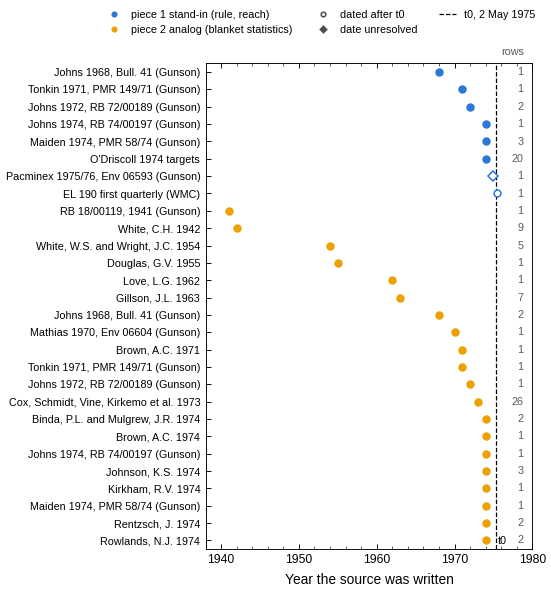

                                  label  piece     status   year  n
          Johns 1968, Bull. 41 (Gunson)      1     before 1968.0  1
       Tonkin 1971, PMR 149/71 (Gunson)      1     before 1971.0  1
       Johns 1972, RB 72/00189 (Gunson)      1     before 1972.0  2
       Johns 1974, RB 74/00197 (Gunson)      1     before 1974.0  1
        Maiden 1974, PMR 58/74 (Gunson)      1     before 1974.0  3
                O'Driscoll 1974 targets      1     before 1974.0 20
   Pacminex 1975/76, Env 06593 (Gunson)      1 unresolved 1975.0  1
           EL 190 first quarterly (WMC)      1      after 1975.5  1
             RB 18/00119, 1941 (Gunson)      2     before 1941.0  1
                       White, C.H. 1942      2     before 1942.0  9
      White, W.S. and Wright, J.C. 1954      2     before 1954.0  5
                     Douglas, G.V. 1955      2     before 1955.0  1
                        Love, L.G. 1962      2     before 1962.0  1
                     Gillson, J.L. 1963      2  

In [3]:
def yr(s):
    y = re.findall(r"(19\d\d)", str(s)); return int(y[0]) if y else np.nan
short = lambda s: re.match(r"(.*?\d{4})", s).group(1)
src = []
for s, g in BS.groupby("source"):
    src.append((short(s), int(g.doc_date.iloc[0]), 2, "before", len(g)))
for s, g in DIM.groupby("source"):
    src.append((short(s), yr(s), 2, "before", len(g)))
MGLAB = {2: ("Johns 1968, Bull. 41", 1), 10: ("Tonkin 1971, PMR 149/71", 1), 20: ("Maiden 1974, PMR 58/74", 1),
         21: ("Maiden 1974, PMR 58/74", 1), 23: ("Maiden 1974, PMR 58/74", 1), 27: ("Johns 1974, RB 74/00197", 1),
         29: ("Pacminex 1975/76, Env 06593", 1), 30: ("Johns 1972, RB 72/00189", 1), 37: ("Johns 1972, RB 72/00189", 1),
         3: ("Johns 1968, Bull. 41", 2), 6: ("RB 18/00119, 1941", 2), 11: ("Tonkin 1971, PMR 149/71", 2),
         22: ("Maiden 1974, PMR 58/74", 2), 36: ("Mathias 1970, Env 06604", 2), 31: ("Johns 1972, RB 72/00189", 2),
         4: ("Johns 1968, Bull. 41", 2), 26: ("Johns 1974, RB 74/00197", 2)}
for i, (lab, pc) in MGLAB.items():
    r = MG.loc[MG.row == i].iloc[0]
    src.append((f"{lab} (Gunson)", yr(r.doc_date), pc, r.status_t0, 1))
src.append(("O'Driscoll 1974 targets", 1974, 1, "before", len(OD)))
src.append(("EL 190 first quarterly (WMC)", 1975.5, 1, "after", 1))
S = (pd.DataFrame(src, columns=["label", "year", "piece", "status", "n"])
       .groupby(["label", "piece", "status"], as_index=False).agg(year=("year", "min"), n=("n", "sum"))
       .sort_values(["piece", "year"]).reset_index(drop=True))
fig, ax = plt.subplots(figsize=(COL15, 0.17 * len(S) + 0.9))
fig.subplots_adjust(left=0.43, right=0.97, top=0.9, bottom=0.12)
ax.axvline(1975 + 121 / 365.25, color="black", lw=0.8, ls="--")
for i, r in S.iterrows():
    c = PIECE_COL[r.piece]
    face = c if r.status == "before" else "white"
    ax.plot(r.year, i, "o" if r.status != "unresolved" else "D", ms=4.5, mfc=face, mec=c, mew=1.0)
    ax.text(1978.9, i, f"{r.n}", va="center", ha="right", fontsize=FS_ANNOT, color="0.35")
ax.set_yticks(range(len(S))); ax.set_yticklabels(S.label, fontsize=FS_ANNOT)
ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(len(S) - 0.5, -0.5)
ax.set_xlim(1938, 1980); ax.set_xlabel("Year the source was written")
ax.text(1975.6, len(S) - 0.7, "t0", va="bottom", ha="left", fontsize=FS_ANNOT)
ax.tick_params(axis="y", which="both", right=False)
ax.text(1978.9, -0.9, "rows", va="bottom", ha="right", fontsize=FS_ANNOT, color="0.35")
h = [plt.Line2D([], [], marker="o", ls="", color=PIECE_COL[1], label="piece 1 stand-in (rule, reach)"),
     plt.Line2D([], [], marker="o", ls="", color=PIECE_COL[2], label="piece 2 analog (blanket statistics)"),
     plt.Line2D([], [], marker="o", ls="", mfc="white", mec="0.3", label="dated after t0"),
     plt.Line2D([], [], marker="D", ls="", mfc="0.3", mec="0.3", label="date unresolved"),
     plt.Line2D([], [], color="black", ls="--", lw=0.8, label="t0, 2 May 1975")]
fig.legend(handles=h, loc="upper center", ncol=3, fontsize=FS_ANNOT, bbox_to_anchor=(0.62, 1.0))
fig.savefig(FIG / "wp4_L4_00_sources_by_date.png", dpi=300)
plt.show()
print(S.to_string(index=False))
print(f"\n{len(S)} sources; piece 1: {int((S.piece == 1).sum())}, piece 2: {int((S.piece == 2).sum())}; "
      f"after t0: {int((S.status == 'after').sum())}; unresolved: {int((S.status == 'unresolved').sum())}; "
      f"oldest {int(S.year.min())}")


### How to read this figure

Each row is one source; its dot sits at the year the source was written, and the dashed line is t0. Blue sources stand in for Haynes's memoranda (piece 1, the rule and its reach), orange sources carry the blanket statistics (piece 2). A filled dot was written before t0, the hollow circle after it, and the diamond has an unresolved date. The number at the right is how many transcribed rows the source contributes. There are 28 sources: 8 for piece 1 and 20 for piece 2, going back to 1941. Only two fall outside the information state: the EL 190 first quarterly, written in the quarter after the licence was granted, and the Pacminex genesis text, signed in March 1975 but filed in July 1976. The picture to take away is that the piece 2 evidence spans thirty years of print, while every piece 1 stand-in comes from 1968 to 1974 and from one district, Mount Gunson, plus O'Driscoll's lineament sheet.


## Part A, basis piece 1: Haynes's memoranda, the rule and its reach

The memoranda are not on disk and not in open file. Part A therefore asks a narrower question: what could a reader at t0 have written down about the rule's three conditions and about the reach d, from the documents that do survive?


### Step A1. Which conditions of the rule each source states

The rule has three conditions and one number. Each source is scored on whether it states, only implies, or is silent on a mafic source near the ore, on reduced facies as the trap, on faults or lineaments as the focusing structure, and on any length that could serve as the reach d. The score for each cell is written in the code with the row it was read from.


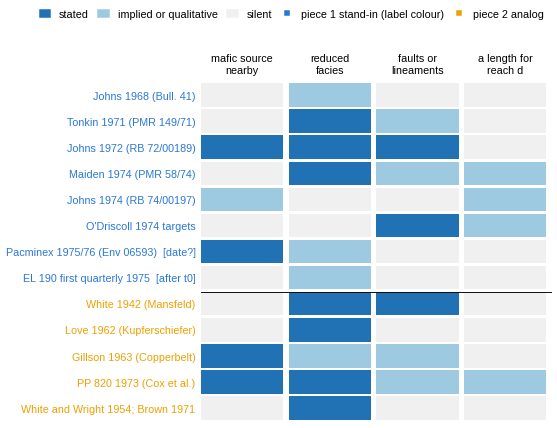

           condition  stated  implied  silent
 mafic source nearby       3        1       7
      reduced facies       7        2       2
faults or lineaments       3        4       4
a length for reach d       0        4       7
pre-t0 sources: 11; stating all three conditions: 1 (['Johns 1972 (RB 72/00189)']); stating a lateral number for d: 0


In [4]:
# what each stand-in says about the three conditions of the rule and about a length for the reach d
# 2 = stated, 1 = implied or qualitative, 0 = silent; each cell cites the row it was read from
COND = ["mafic source\nnearby", "reduced\nfacies", "faults or\nlineaments", "a length for\nreach d"]
EV = [  # source, piece, status, cells, citation
    ("Johns 1968 (Bull. 41)", 1, "before", [0, 1, 0, 0], "G2 shoreline and reef"),
    ("Tonkin 1971 (PMR 149/71)", 1, "before", [0, 2, 1, 0], "G10 black dolomitic shale, depressions"),
    ("Johns 1972 (RB 72/00189)", 1, "before", [2, 2, 2, 0], "G30, G37 dyke swarm, 500 ppm Cu dolerite, fractures"),
    ("Maiden 1974 (PMR 58/74)", 1, "before", [0, 2, 1, 1], "G20, G21, G23 oxidising-to-reducing change; 15 km from basin edge"),
    ("Johns 1974 (RB 74/00197)", 1, "before", [1, 0, 0, 1], "G27 basalt over 200 m under the Pandurra (vertical)"),
    ("O'Driscoll 1974 targets", 1, "before", [0, 0, 2, 1], "20 lineament targets, circles of about 5 km radius"),
    ("Pacminex 1975/76 (Env 06593)", 1, "unresolved", [2, 1, 0, 0], "G29 basic igneous activity as the Cu source"),
    ("EL 190 first quarterly 1975", 1, "after", [0, 1, 0, 0], "stratiform Cu, Cattle Grid at the unconformity"),
    ("White 1942 (Mansfeld)", 2, "before", [0, 2, 2, 0], "rows 33, 34 red cap barren; ore near faults"),
    ("Love 1962 (Kupferschiefer)", 2, "before", [0, 2, 0, 0], "row 43 no aerated episodes"),
    ("Gillson 1963 (Copperbelt)", 2, "before", [2, 1, 1, 0], "rows 41, 42, 39 gabbro near each deposit; zoning; lineament"),
    ("PP 820 1973 (Cox et al.)", 2, "before", [2, 2, 1, 1], "rows 18, 17, 19, 16 environment 10; coincidence; 110-1,850 m vertical"),
    ("White and Wright 1954; Brown 1971", 2, "before", [0, 2, 0, 0], "L3 rows 14, 15 grey Nonesuch over red beds"),
]
M = np.array([e[3] for e in EV])
CELL = {0: "#f0f0f0", 1: "#9ecae1", 2: "#2171b5"}
fig, ax = plt.subplots(figsize=(COL15, 0.2 * len(EV) + 1.1))
fig.subplots_adjust(left=0.40, right=0.98, top=0.87, bottom=0.03)
for i, e in enumerate(EV):
    for j, v in enumerate(e[3]):
        ax.add_patch(plt.Rectangle((j, i), 0.94, 0.9, color=CELL[v], lw=0))
ax.set_xlim(0, len(COND)); ax.set_ylim(len(EV), -0.1)
ax.set_xticks(np.arange(len(COND)) + 0.47); ax.set_xticklabels(COND, fontsize=FS_ANNOT)
ax.xaxis.tick_top(); ax.tick_params(which="both", length=0)
ax.set_yticks(np.arange(len(EV)) + 0.45)
ax.set_yticklabels([e[0] + ("  [after t0]" if e[2] == "after" else "  [date?]" if e[2] == "unresolved" else "") for e in EV],
                   fontsize=FS_ANNOT)
for t, e in zip(ax.get_yticklabels(), EV):
    t.set_color(PIECE_COL[e[1]])
ax.xaxis.set_minor_locator(plt.NullLocator()); ax.yaxis.set_minor_locator(plt.NullLocator())
for s in ax.spines.values(): s.set_visible(False)
ax.axhline(8, color="black", lw=0.6)
h = [plt.Rectangle((0, 0), 1, 1, color=CELL[k], label=l) for k, l in
     [(2, "stated"), (1, "implied or qualitative"), (0, "silent")]]
h += [plt.Line2D([], [], ls="", marker="s", color=PIECE_COL[1], label="piece 1 stand-in (label colour)"),
      plt.Line2D([], [], ls="", marker="s", color=PIECE_COL[2], label="piece 2 analog")]
fig.legend(handles=h, loc="lower center", ncol=5, fontsize=FS_ANNOT, bbox_to_anchor=(0.55, 1.0),
           handlelength=1.0, columnspacing=0.9)
fig.savefig(FIG / "wp4_L4_A1_rule_evidence.png", dpi=300)
plt.show()
pre = [e for e in EV if e[2] == "before"]
Mp = np.array([e[3] for e in pre])
print(pd.DataFrame([(c.replace("\n", " "), int((Mp[:, j] == 2).sum()), int((Mp[:, j] == 1).sum()), int((Mp[:, j] == 0).sum()))
                    for j, c in enumerate(COND)], columns=["condition", "stated", "implied", "silent"]).to_string(index=False))
print(f"pre-t0 sources: {len(pre)}; stating all three conditions: {sum(1 for e in pre if min(e[3][:3]) == 2)} "
      f"({[e[0] for e in pre if min(e[3][:3]) == 2]}); stating a lateral number for d: 0")


### How to read this figure

Rows are sources (blue labels piece 1 stand-ins above the black line, orange labels piece 2 analogs below it); columns are the three conditions of the rule and a length for its reach. Dark blue means the source states the condition, light blue that it implies it or says it qualitatively, pale grey that it is silent. Of the 11 sources written before t0, reduced facies is stated by 7, a mafic source by 3 (Johns 1972 at Mount Gunson, Gillson 1963 on the Copperbelt gabbros, PP 820 environment 10), and faults or lineaments by 3. Only one source, Johns (1972, RB 72/00189), states all three together: a swarm of basic dykes and fractures in the Pernatty Culmination under the reduced Woocalla trap. No source states a lateral length for d; the four light cells in the last column are lengths measured from something else, taken up in the next step. The rule as a combination therefore has a pre-t0 author, but its reach does not.


### Step A2. Every pre-t0 length that bears on the reach d

The annex puts d at 0 to 10 km. Here every length written before t0 that a modeller might be tempted to use for d is drawn on one axis, labelled by what it is measured from.


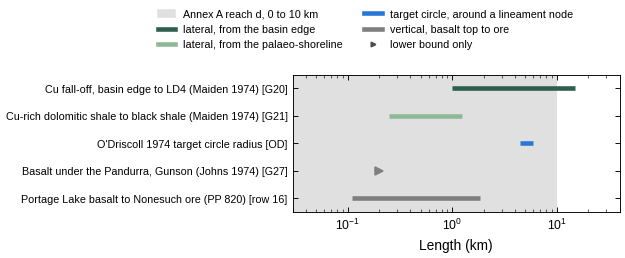

                                               label   lo    hi                                   kind    ref
        Cu fall-off, basin edge to LD4 (Maiden 1974) 1.00 15.00           lateral, from the basin edge    G20
Cu-rich dolomitic shale to black shale (Maiden 1974) 0.25  1.25     lateral, from the palaeo-shoreline    G21
                O'Driscoll 1974 target circle radius 4.50  6.00 target circle, around a lineament node     OD
      Basalt under the Pandurra, Gunson (Johns 1974) 0.20  0.20            vertical, basalt top to ore    G27
        Portage Lake basalt to Nonesuch ore (PP 820) 0.11  1.85            vertical, basalt top to ore row 16
lateral lengths measured from a mafic body before t0: 0


In [5]:
# every pre-t0 length that bears on the reach d, with what it is measured from
r16 = R(16, "basalt to ore"); g20 = G(20, "zoning"); g21 = G(21, "zoning"); g27 = G(27, "stratigraphy")
LEN = pd.DataFrame([
    ("Cu fall-off, basin edge to LD4 (Maiden 1974)", 1.0, 15.0, "lateral, from the basin edge", "G20"),
    ("Cu-rich dolomitic shale to black shale (Maiden 1974)", 0.25, 1.25, "lateral, from the palaeo-shoreline", "G21"),
    ("O'Driscoll 1974 target circle radius", OD.radius_km.min(), OD.radius_km.max(), "target circle, around a lineament node", "OD"),
    ("Basalt under the Pandurra, Gunson (Johns 1974)", 0.2, 0.2, "vertical, basalt top to ore", "G27"),
    ("Portage Lake basalt to Nonesuch ore (PP 820)", *[v / 1000 for v in num(r16.value)], "vertical, basalt top to ore", "row 16"),
], columns=["label", "lo", "hi", "kind", "ref"])
KIND_COL = {"lateral, from the basin edge": GUNSON_COL, "lateral, from the palaeo-shoreline": "#8fb996",
            "target circle, around a lineament node": PIECE_COL[1], "vertical, basalt top to ore": "#7f7f7f"}
fig, ax = plt.subplots(figsize=(COL15, 2.4))
fig.subplots_adjust(left=0.43, right=0.97, top=0.72, bottom=0.2)
ax.axvspan(0.03, 10, color=ANNEX_GREY, lw=0)
for i, r in LEN.iterrows():
    c = KIND_COL[r.kind]
    if r.lo == r.hi:
        ax.plot(r.lo, i, marker=">", color=c, ms=5)          # lower bound only
    else:
        ax.plot([r.lo, r.hi], [i, i], color=c, lw=3, solid_capstyle="butt")
ax.set_xscale("log"); ax.set_xlim(0.03, 40)
ax.set_yticks(range(len(LEN))); ax.set_yticklabels([f"{l} [{f}]" for l, f in zip(LEN.label, LEN.ref)], fontsize=FS_ANNOT)
ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(len(LEN) - 0.5, -0.5)
ax.set_xlabel("Length (km)")
h = [plt.Rectangle((0, 0), 1, 1, color=ANNEX_GREY, label="Annex A reach d, 0 to 10 km")]
h += [plt.Line2D([], [], color=c, lw=3, label=k) for k, c in KIND_COL.items()]
h += [plt.Line2D([], [], color="0.3", marker=">", ls="", label="lower bound only")]
fig.legend(handles=h, loc="upper center", ncol=2, fontsize=FS_ANNOT, bbox_to_anchor=(0.55, 1.0))
fig.savefig(FIG / "wp4_L4_A2_reach_lengths.png", dpi=300)
plt.show()
print(LEN.to_string(index=False))
print(f"lateral lengths measured from a mafic body before t0: {int(LEN.kind.str.contains('mafic').sum())}")


### How to read this figure

Each bar is a range of lengths in kilometres on a logarithmic axis; a triangle is a lower bound only. The grey band is the annex reach, 0 to 10 km. Bar colour says what the length is measured from: dark green from the basin edge, light green from the palaeo-shoreline, blue the radius of O'Driscoll's 1974 target circles around lineament nodes (4.5 to 6.0 km over his 20 targets), grey the vertical gap between the top of a basalt and the ore above it. The lengths that sit inside the annex band are real, but none is a lateral distance from a basalt margin: Maiden's copper fall-off over 1 to 15 km is measured from the edge of the Woocalla basin, and the two basalt figures (at least 0.2 km under the Pandurra at Gunson, 0.11 to 1.85 km under the Nonesuch at White Pine) are vertical. The count printed under the figure, zero lateral lengths from a mafic body, is the finding: d has era bounds of the right order but no era value.


### Step A3. How much of the reduced host is ore

The annex gives P(ore | margin, reduced) as 0.05 to 0.3. The nearest pre-t0 handle is the fraction of a reduced host that turned out to be ore, as the analog papers state it or as their stated counts and lengths give it.


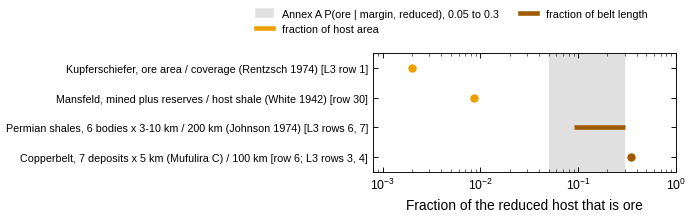

                                                     label     lo     hi        measure                 ref
       Kupferschiefer, ore area / coverage (Rentzsch 1974) 0.0020 0.0020           area            L3 row 1
   Mansfeld, mined plus reserves / host shale (White 1942) 0.0086 0.0086           area              row 30
Permian shales, 6 bodies x 3-10 km / 200 km (Johnson 1974) 0.0900 0.3000 along the belt        L3 rows 6, 7
       Copperbelt, 7 deposits x 5 km (Mufulira C) / 100 km 0.3500 0.3500 along the belt row 6; L3 rows 3, 4


In [6]:
# ore as a fraction of the reduced host, the analog handle on P(ore | margin, reduced)
d1, d6, d7 = D(1, "ore fraction"), D(6, "belt length"), D(7, "patch length")
r30 = R(30, "ore area fraction")
d4, d3 = D(4, "ore patch length"), D(3, "belt length")
FR = pd.DataFrame([
    ("Kupferschiefer, ore area / coverage (Rentzsch 1974)", 0.002, 0.002, "area", "L3 row 1"),
    ("Mansfeld, mined plus reserves / host shale (White 1942)", float(r30.value), float(r30.value), "area", "row 30"),
    ("Permian shales, 6 bodies x 3-10 km / 200 km (Johnson 1974)", 6 * 3 / 200, 6 * 10 / 200, "along the belt", "L3 rows 6, 7"),
    ("Copperbelt, 7 deposits x 5 km (Mufulira C) / 100 km", 7 * 5 / 100, 7 * 5 / 100, "along the belt", "row 6; L3 rows 3, 4"),
], columns=["label", "lo", "hi", "measure", "ref"])
MEAS_COL = {"area": PIECE_COL[2], "along the belt": "#a05a00"}
fig, ax = plt.subplots(figsize=(COL15, 2.0))
fig.subplots_adjust(left=0.47, right=0.97, top=0.78, bottom=0.24)
ax.axvspan(0.05, 0.3, color=ANNEX_GREY, lw=0)
for i, r in FR.iterrows():
    c = MEAS_COL[r.measure]
    if r.lo == r.hi: ax.plot(r.lo, i, "o", color=c, ms=4.5)
    else: ax.plot([r.lo, r.hi], [i, i], color=c, lw=3, solid_capstyle="butt")
ax.set_xscale("log"); ax.set_xlim(8e-4, 1)
ax.set_yticks(range(len(FR))); ax.set_yticklabels([f"{l} [{f}]" for l, f in zip(FR.label, FR.ref)], fontsize=FS_ANNOT)
ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(len(FR) - 0.5, -0.5)
ax.set_xlabel("Fraction of the reduced host that is ore")
h = [plt.Rectangle((0, 0), 1, 1, color=ANNEX_GREY, label="Annex A P(ore | margin, reduced), 0.05 to 0.3"),
     plt.Line2D([], [], color=MEAS_COL["area"], lw=3, label="fraction of host area"),
     plt.Line2D([], [], color=MEAS_COL["along the belt"], lw=3, label="fraction of belt length")]
fig.legend(handles=h, loc="upper center", ncol=2, fontsize=FS_ANNOT, bbox_to_anchor=(0.6, 1.02))
fig.savefig(FIG / "wp4_L4_A3_ore_fractions.png", dpi=300)
plt.show()
print(FR.to_string(index=False))


### How to read this figure

Each mark is one analog on a logarithmic axis of ore fraction; the grey band is the annex range 0.05 to 0.3. Light orange marks are fractions of the host's area: the Kupferschiefer ore areas are about 0.2% of the shale's coverage (Rentzsch 1974), and at Mansfeld 60 square miles mined or in reserve against a 7,000 square mile shale give 0.0086 (White 1942). Dark orange marks are fractions of a belt's length: six Permian copper-shale bodies of 3 to 10 km along 200 km of outcrop give 0.09 to 0.30, and seven Copperbelt deposits of about 5 km (the Mufulira C orebody length) along the 100 km Ore Shale give 0.35. The two measures differ by two orders of magnitude, and the annex band matches only the along-belt fraction. That is the right comparison only if the "margin" in the rule already confines the model to a belt a few kilometres wide; over a whole reduced basin the era numbers are 0.002 to 0.009.


### Verdict on piece 1

Haynes's memoranda remain NOT FOUND, and the stand-ins do not replace them for the reach. What the pre-t0 record does support is the shape of the rule: a mafic source, a reduced trap and a fracture system were written down together for Mount Gunson in 1972, and the PP 820 list of favourable environments (1973) names "porous strata updip and marginal to" buried basalt. What it does not support is any number for d or for the lineament multiplier. The reach can be carried with era bounds (a lateral chemical gradient over 1 to 15 km at Gunson; target circles of about 5 km on O'Driscoll's sheet) but its value is testimony until the memoranda are obtained. The occurrence probability is scale-dependent: 0.002 to 0.009 over a basin, 0.09 to 0.35 along a belt.


## Part B, basis piece 2: the analog blanket statistics as known by 1975

The annex names the Zambian Copperbelt, White Pine and the Kupferschiefer. Part B puts what was in print about their size, grade and thickness beside the Mount Gunson figures, the analog WMC's own concept used, and compares each with the annex blanket.


### Step B1. Grade and tonnage

The first test is the annex box itself, 1 to 4% Cu and tens of millions of tonnes. Every deposit with a stated tonnage and grade before t0 is placed on the grade-tonnage plane used by PP 820's own figure 22.


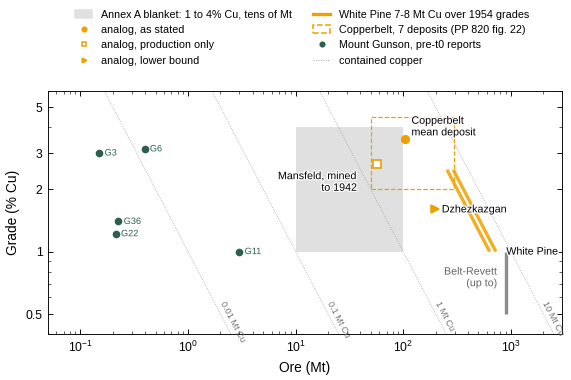

Copperbelt mean deposit 104 Mt at 3.5% (envelope 50-299 Mt, 2.0-4.5%)
Mansfeld mined to 1942 57 Mt at 2.65%; Dzhezkazgan > 198 Mt at 1.6%
White Pine 6.4-7.3 Mt Cu -> 255-726 Mt ore at 2.49-1.0%
ref    Mt  grade
 G3 0.150  3.000
 G6 0.395  3.140
G11 3.000  1.000
G22 0.213  1.220
G36 0.226  1.399
inside the Annex A box: {'Copperbelt mean': False, 'Mansfeld': np.True_, 'Dzhezkazgan': False, 'Gunson any': False}


In [7]:
# grade and tonnage as stated before t0, in tonnes of ore and percent Cu
r7, r8, r9, r10 = R(7, "contained Cu"), R(8, "mean grade"), R(9, "tonnage"), R(10, "grade range")
r14, r45, r46 = R(14, "production plus reserves"), R(45, "ore grade"), R(46, "sample grade")
r31, r32, r21, r22 = R(31, "cumulative"), R(32, "mined grade"), R(21, "contained Cu"), R(22, "tonnage and grade")
g3, g6, g11, g22, g36 = [G(i, "grade-tonnage") for i in (3, 6, 11, 22, 36)]
cb_t = float(r7.value) / (float(r8.value) / 100) * ST                   # mean Copperbelt deposit
mf_g = np.mean(num(r32.value)); mf_t = num(r31.value)[0] / (mf_g / 100)  # Mansfeld ore mined to 1942
dz_cu, dz_g = num(r21.value); dz_t = dz_cu / (dz_g / 100) * ST
wp_cu = np.array(num(r14.value)) * ST; wp_g = np.array([1.0, 2.49])     # 7-8 Mt Cu over the 1954 grades
GU = pd.DataFrame([(f"G{g.row}", num(g.value)[0] / 1e6, num(g.unit)[0]) for g in (g3, g6, g11, g22)] +
                  [("G36", (203 + 46) / 1000 * ST, (203 * 1.43 + 46 * 1.26) / 249)], columns=["ref", "Mt", "grade"])
fig, ax = plt.subplots(figsize=(COL15, 3.4))
fig.subplots_adjust(left=0.12, right=0.97, top=0.78, bottom=0.13)
ax.add_patch(plt.Rectangle((10, 1), 90, 3, color=ANNEX_GREY, lw=0, zorder=0))
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(0.05, 3000); ax.set_ylim(0.4, 6)
fig.canvas.draw()
p0, p1 = ax.transData.transform([(1, 1), (10, 0.1)])
ang = np.degrees(np.arctan2(p1[1] - p0[1], p1[0] - p0[0]))
for cu in [0.01, 0.1, 1, 10]:
    t = np.array([0.03, 3000]); ax.plot(t, cu / t * 100, color="0.6", lw=0.5, ls=":", zorder=1)
    ax.text(cu / 0.56 * 100 * 1.06, 0.56, f"{cu:g} Mt Cu", fontsize=FS_ANNOT - 1, color="0.45",
            rotation=ang, rotation_mode="anchor", ha="left", va="bottom")
lo9, hi9 = [v * ST for v in num(r9.value)]; lo10, hi10 = num(r10.value)
ax.add_patch(plt.Rectangle((lo9, lo10), hi9 - lo9, hi10 - lo10, fill=False, ec=PIECE_COL[2], lw=0.8, ls="--"))
ax.plot(cb_t, float(r8.value), "o", color=PIECE_COL[2], ms=5, zorder=4)
ax.text(cb_t * 1.15, float(r8.value) + 0.15, "Copperbelt\nmean deposit", fontsize=FS_ANNOT, path_effects=HALO)
ax.plot(mf_t, mf_g, "s", mfc="white", mec=PIECE_COL[2], mew=1.1, ms=5, zorder=4)
ax.text(mf_t / 1.5, mf_g - 0.2, "Mansfeld, mined\nto 1942", fontsize=FS_ANNOT, ha="right", va="top", path_effects=HALO)
ax.plot(dz_t, dz_g, marker=">", color=PIECE_COL[2], ms=5, zorder=4)
ax.text(dz_t * 1.15, dz_g, "Dzhezkazgan", fontsize=FS_ANNOT, va="center", path_effects=HALO)
for cu in wp_cu:
    ax.plot(cu / (wp_g / 100), wp_g, color=PIECE_COL[2], lw=2.2, solid_capstyle="butt", alpha=0.85)
ax.text(wp_cu.max() / 0.01 * 1.25, 1.0, "White Pine", fontsize=FS_ANNOT, va="center", path_effects=HALO)
bt = num(r22.value)[0] * ST; bg = num(r22.value)[1:]
ax.plot([bt, bt], bg, color="0.55", lw=2.2, solid_capstyle="butt")
ax.text(bt / 1.2, np.mean(bg), "Belt-Revett\n(up to)", fontsize=FS_ANNOT, ha="right", va="center", color="0.4", path_effects=HALO)
ax.scatter(GU.Mt, GU.grade, s=16, color=GUNSON_COL, zorder=5)
for _, g in GU.iterrows():
    ax.text(g.Mt * 1.12, g.grade, g.ref, fontsize=FS_ANNOT - 1, va="center", color=GUNSON_COL, path_effects=HALO)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(0.05, 3000); ax.set_ylim(0.4, 6)
ax.set_yticks([0.5, 1, 2, 3, 5]); ax.set_yticklabels(["0.5", "1", "2", "3", "5"])
ax.set_xlabel("Ore (Mt)"); ax.set_ylabel("Grade (% Cu)")
h = [plt.Rectangle((0, 0), 1, 1, color=ANNEX_GREY, label="Annex A blanket: 1 to 4% Cu, tens of Mt"),
     plt.Line2D([], [], marker="o", ls="", color=PIECE_COL[2], label="analog, as stated"),
     plt.Line2D([], [], marker="s", ls="", mfc="white", mec=PIECE_COL[2], label="analog, production only"),
     plt.Line2D([], [], marker=">", ls="", color=PIECE_COL[2], label="analog, lower bound"),
     plt.Line2D([], [], color=PIECE_COL[2], lw=2.2, label="White Pine 7-8 Mt Cu over 1954 grades"),
     plt.Rectangle((0, 0), 1, 1, fill=False, ec=PIECE_COL[2], ls="--", label="Copperbelt, 7 deposits (PP 820 fig. 22)"),
     plt.Line2D([], [], marker="o", ls="", color=GUNSON_COL, label="Mount Gunson, pre-t0 reports"),
     plt.Line2D([], [], color="0.6", ls=":", lw=0.6, label="contained copper")]
fig.legend(handles=h, loc="upper center", ncol=2, fontsize=FS_ANNOT, bbox_to_anchor=(0.54, 1.02))
fig.savefig(FIG / "wp4_L4_B1_grade_tonnage.png", dpi=300)
plt.show()
print(f"Copperbelt mean deposit {cb_t:.0f} Mt at {float(r8.value)}% (envelope {lo9:.0f}-{hi9:.0f} Mt, {lo10}-{hi10}%)")
print(f"Mansfeld mined to 1942 {mf_t:.0f} Mt at {mf_g:.2f}%; Dzhezkazgan > {dz_t:.0f} Mt at {dz_g}%")
print(f"White Pine {wp_cu.min():.1f}-{wp_cu.max():.1f} Mt Cu -> {wp_cu.min()/0.0249:.0f}-{wp_cu.max()/0.01:.0f} Mt ore at 2.49-1.0%")
print(GU.round(3).to_string(index=False))
inbox = lambda t, g: (10 <= t <= 100) & (1 <= g <= 4)
print("inside the Annex A box:", {"Copperbelt mean": inbox(cb_t, 3.5), "Mansfeld": inbox(mf_t, mf_g),
      "Dzhezkazgan": inbox(dz_t, dz_g), "Gunson any": bool(any(inbox(t, g) for t, g in zip(GU.Mt, GU.grade)))})


### How to read this figure

The horizontal axis is tonnes of ore per deposit and the vertical axis its copper grade, both logarithmic; the dotted diagonals are lines of equal contained copper. The grey box is the annex blanket. Orange marks are the world analogs: the mean Copperbelt deposit (4 Mt of copper at 3.5%, so 104 Mt of ore) inside the dashed envelope of the seven Zaire and Zambia deposits of PP 820 figure 22 (50 to 299 Mt at 2.0 to 4.5%, read from the figure by eye); Mansfeld's production to 1942 (57 Mt at 2.65%, hollow because reserves are left out); Dzhezkazgan as a lower bound (over 198 Mt at 1.6%); White Pine as two short bars along its 6.4 and 7.3 Mt of copper, spread over the 1.0 to 2.49% grades that White and Wright reported in 1954, which gives 255 to 726 Mt; and the low-grade Belt-Revett ceiling in grey. Green dots are the Mount Gunson figures, 0.15 to 3.0 Mt at 1.0 to 3.1%. The grade range of the annex is supported by all three named analogs. The tonnage box is not: only Mansfeld falls inside it, the Copperbelt mean sits just above it, White Pine far above, and every Gunson figure lies below it, by a factor of 3 to 67 from its 10 Mt edge.


### Step B2. Thickness of the ore bed

The annex blanket is 2 to 30 m thick. The pre-t0 thicknesses are drawn with a distinction the annex does not make: the ore bed itself versus the host formation or mineralised section it sits in.


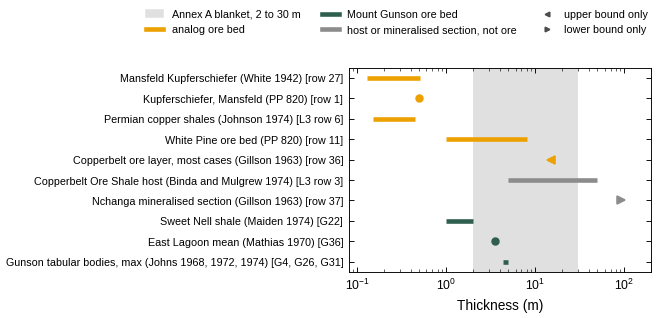

                                              label    lo    hi                        kind          ref  grp
               Mansfeld Kupferschiefer (White 1942)  0.13  0.51                     ore bed       row 27    2
                  Kupferschiefer, Mansfeld (PP 820)  0.50  0.50                     ore bed        row 1    2
               Permian copper shales (Johnson 1974)  0.15  0.45                     ore bed     L3 row 6    2
                        White Pine ore bed (PP 820)  1.00  8.00                     ore bed       row 11    2
    Copperbelt ore layer, most cases (Gillson 1963)   NaN 15.20                     ore bed       row 36    2
 Copperbelt Ore Shale host (Binda and Mulgrew 1974)  5.00 50.00 host or mineralised section     L3 row 3    2
         Nchanga mineralised section (Gillson 1963) 91.40   NaN host or mineralised section       row 37    2
                     Sweet Nell shale (Maiden 1974)  1.00  2.00                     ore bed          G22    1
          

In [8]:
# ore-bed thickness as stated before t0, against the Annex A blanket thickness
r1, r27, r11, r36, r37 = R(1, "thickness"), R(27, "ore bed thickness"), R(11, "ore bed thickness"), R(36, "ore layer"), R(37, "mineralized section")
d3, d6 = D(3, "belt length"), D(6, "belt length")
g4, g26, g22, g36, g31 = G(4, "geometry"), G(26, "geometry"), G(22, "grade-tonnage"), G(36, "grade-tonnage"), G(31, "geometry")
TH = pd.DataFrame([
    ("Mansfeld Kupferschiefer (White 1942)", *num(r27.value)[:2], "ore bed", "row 27", 2),
    ("Kupferschiefer, Mansfeld (PP 820)", 0.5, 0.5, "ore bed", "row 1", 2),
    ("Permian copper shales (Johnson 1974)", 0.15, 0.45, "ore bed", "L3 row 6", 2),
    ("White Pine ore bed (PP 820)", *num(r11.value), "ore bed", "row 11", 2),
    ("Copperbelt ore layer, most cases (Gillson 1963)", np.nan, 15.2, "ore bed", "row 36", 2),
    ("Copperbelt Ore Shale host (Binda and Mulgrew 1974)", 5, 50, "host or mineralised section", "L3 row 3", 2),
    ("Nchanga mineralised section (Gillson 1963)", 91.4, np.nan, "host or mineralised section", "row 37", 2),
    ("Sweet Nell shale (Maiden 1974)", 1, 2, "ore bed", "G22", 1),
    ("East Lagoon mean (Mathias 1970)", 3.5, 3.5, "ore bed", "G36", 1),
    ("Gunson tabular bodies, max (Johns 1968, 1972, 1974)", 4.3, 5.0, "ore bed", "G4, G26, G31", 1),
], columns=["label", "lo", "hi", "kind", "ref", "grp"])
fig, ax = plt.subplots(figsize=(COL15, 2.9))
fig.subplots_adjust(left=0.47, right=0.97, top=0.8, bottom=0.16)
ax.axvspan(2, 30, color=ANNEX_GREY, lw=0)
for i, r in TH.iterrows():
    c = GUNSON_COL if r.grp == 1 else PIECE_COL[2]
    if r.kind != "ore bed": c = "0.55"
    if np.isnan(r.lo): ax.plot(r.hi, i, marker="<", color=c, ms=5)
    elif np.isnan(r.hi): ax.plot(r.lo, i, marker=">", color=c, ms=5)
    elif r.lo == r.hi: ax.plot(r.lo, i, "o", color=c, ms=4.5)
    else: ax.plot([r.lo, r.hi], [i, i], color=c, lw=3, solid_capstyle="butt")
ax.set_xscale("log"); ax.set_xlim(0.08, 200)
ax.set_yticks(range(len(TH))); ax.set_yticklabels([f"{l} [{f}]" for l, f in zip(TH.label, TH.ref)], fontsize=FS_ANNOT)
ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(len(TH) - 0.5, -0.5)
ax.set_xlabel("Thickness (m)")
h = [plt.Rectangle((0, 0), 1, 1, color=ANNEX_GREY, label="Annex A blanket, 2 to 30 m"),
     plt.Line2D([], [], color=PIECE_COL[2], lw=3, label="analog ore bed"),
     plt.Line2D([], [], color=GUNSON_COL, lw=3, label="Mount Gunson ore bed"),
     plt.Line2D([], [], color="0.55", lw=3, label="host or mineralised section, not ore"),
     plt.Line2D([], [], color="0.3", marker="<", ls="", label="upper bound only"),
     plt.Line2D([], [], color="0.3", marker=">", ls="", label="lower bound only")]
fig.legend(handles=h, loc="upper center", ncol=3, fontsize=FS_ANNOT, bbox_to_anchor=(0.55, 1.01))
fig.savefig(FIG / "wp4_L4_B2_thickness.png", dpi=300)
plt.show()
ore = TH[TH.kind == "ore bed"]
top = ore.hi.fillna(ore.lo)
print(TH.to_string(index=False))
print(f"ore beds: {len(ore)}; entirely below 2 m: {int((top < 2).sum())}; reaching into 2-30 m: {int(((top >= 2)).sum())}; "
      f"above 30 m: {int((ore.lo > 30).sum())}")


### How to read this figure

Each bar is a thickness range in metres on a logarithmic axis, a dot a single value, and a triangle a bound (pointing left for an upper bound, right for a lower bound). The grey band is the annex 2 to 30 m. Orange bars are analog ore beds, green bars Mount Gunson ore beds, and grey bars are host formations or mineralised sections that are not ore. Of the 8 ore beds, 3 lie wholly below 2 m: the Kupferschiefer at Mansfeld (0.13 to 0.51 m, average about 0.23 m) and the Permian copper shales (0.15 to 0.45 m). White Pine (1 to 8 m), the Copperbelt ore layer (under 15 m in most cases, Gillson 1963) and the Gunson bodies (1 to 5 m) reach into the lower part of the band. Nothing written before t0 gives an ore bed over 15 m; the larger numbers, 5 to 50 m for the Copperbelt Ore Shale and over 91 m of mineralised section at Nchanga, describe the host, not the ore. The annex range therefore describes a Copperbelt-type blanket at its upper half and excludes the Kupferschiefer altogether.


### Step B3. The tonnage distribution

The annex asks for a lognormal tonnage with median tens of millions of tonnes. The nine deposit tonnages stated before t0 (six at Gunson, three world analogs) are put in one cumulative distribution and fitted with a lognormal.


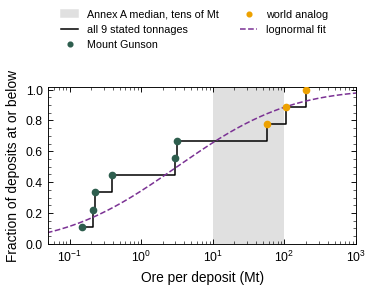

             ref      Mt        group
              G3   0.150 Mount Gunson
              G6   0.395 Mount Gunson
             G11   3.000 Mount Gunson
             G22   0.213 Mount Gunson
             G36   0.226 Mount Gunson
             G31   3.200 Mount Gunson
 Copperbelt mean 103.680 world analog
Mansfeld to 1942  56.604 world analog
     Dzhezkazgan 198.450 world analog
lognormal fit, all: median 3.2 Mt, log10 sd 1.24 (5-95%: 0.03-350 Mt)
  all           sample median     3.00 Mt, log10 sd 1.24, n=9
  Mount Gunson  sample median     0.30 Mt, log10 sd 0.60, n=6
  world analog  sample median   103.68 Mt, log10 sd 0.27, n=3
gap between the largest Gunson tonnage and the smallest world analog: 1.25 log10 units (18x)


In [9]:
# deposit tonnages as stated before t0, and a lognormal fitted to them
TN = pd.concat([GU[["ref", "Mt"]].assign(group="Mount Gunson"),
                pd.DataFrame([("G31", num(g31.value)[0] / 1e6, "Mount Gunson"),
                              ("Copperbelt mean", cb_t, "world analog"), ("Mansfeld to 1942", mf_t, "world analog"),
                              ("Dzhezkazgan", dz_t, "world analog")], columns=["ref", "Mt", "group"])], ignore_index=True)
x = np.log10(TN.Mt.values)
fits = {k: (np.median(v), v.std(ddof=1)) for k, v in
        {"all": x, "Mount Gunson": x[TN.group == "Mount Gunson"], "world analog": x[TN.group == "world analog"]}.items()}
fig, ax = plt.subplots(figsize=(COL1, 2.6))
fig.subplots_adjust(left=0.17, right=0.97, top=0.72, bottom=0.17)
ax.axvspan(10, 100, color=ANNEX_GREY, lw=0)
xs = np.sort(x); ax.step(10 ** xs, np.arange(1, len(xs) + 1) / len(xs), where="post", color="black", lw=1.0)
for g, c in [("Mount Gunson", GUNSON_COL), ("world analog", PIECE_COL[2])]:
    s = TN[TN.group == g]; rk = np.searchsorted(xs, np.log10(s.Mt), side="right") / len(xs)
    ax.plot(s.Mt, rk, "o", color=c, ms=4, zorder=4)
grid = np.linspace(-2, 3.5, 300)
mu, sd = x.mean(), x.std(ddof=1)
ax.plot(10 ** grid, stats.norm.cdf(grid, mu, sd), color="#7b3294", lw=1.0, ls="--")
ax.set_xscale("log"); ax.set_xlim(0.05, 1000); ax.set_ylim(0, 1.02)
ax.set_xlabel("Ore per deposit (Mt)"); ax.set_ylabel("Fraction of deposits at or below")
h = [plt.Rectangle((0, 0), 1, 1, color=ANNEX_GREY, label="Annex A median, tens of Mt"),
     plt.Line2D([], [], color="black", lw=1.0, label=f"all {len(x)} stated tonnages"),
     plt.Line2D([], [], marker="o", ls="", color=GUNSON_COL, label="Mount Gunson"),
     plt.Line2D([], [], marker="o", ls="", color=PIECE_COL[2], label="world analog"),
     plt.Line2D([], [], color="#7b3294", ls="--", label="lognormal fit")]
fig.legend(handles=h, loc="upper center", ncol=2, fontsize=FS_ANNOT, bbox_to_anchor=(0.55, 1.02))
fig.savefig(FIG / "wp4_L4_B3_tonnage_distribution.png", dpi=300)
plt.show()
print(TN.round(3).to_string(index=False))
print(f"lognormal fit, all: median {10**mu:.1f} Mt, log10 sd {sd:.2f} (5-95%: {10**(mu-1.645*sd):.2f}-{10**(mu+1.645*sd):.0f} Mt)")
for k, (m, s) in fits.items():
    print(f"  {k:13s} sample median {10**m:8.2f} Mt, log10 sd {s:.2f}, n={int(((TN.group == k) | (k == 'all')).sum())}")
gap = x[TN.group == "world analog"].min() - x[TN.group == "Mount Gunson"].max()
print(f"gap between the largest Gunson tonnage and the smallest world analog: {gap:.2f} log10 units ({10**gap:.0f}x)")


### How to read this figure

The step line is the fraction of the nine stated deposits whose ore tonnage is at or below each value on the horizontal axis (logarithmic); green dots are Mount Gunson figures, orange dots the Copperbelt mean deposit, Mansfeld to 1942 and Dzhezkazgan. The dashed purple curve is a lognormal fitted to all nine, and the grey band is the annex median of tens of millions of tonnes. The fit has a median of 3.2 Mt and a standard deviation of 1.24 in log10 units, so its 5 to 95% range runs from 0.03 to 350 Mt. The data are not one lognormal: the Gunson figures cluster at a median of 0.30 Mt, the world analogs at 104 Mt, and the gap between the largest Gunson figure and the smallest world analog is a factor of 18 with nothing stated in between. The annex median falls in exactly that empty gap. A reader at t0 who took Gunson as the model would expect deposits a hundred times smaller than one who took the named world analogs.


### Verdict on piece 2

Piece 2 is now largely in state. Grade is supported by every named analog (Copperbelt 2 to 4.5%, Mansfeld 2.5 to 2.8%, White Pine 1 to 2.5%) and by Mount Gunson. Thickness is supported for a Copperbelt or White Pine type bed in the lower half of the annex range; the Kupferschiefer ore bed is ten times thinner than the annex floor, and no ore bed over 15 m is in the pre-t0 record. Tonnage is bimodal: the named world analogs are 57 to 198 Mt per deposit, Gunson 0.15 to 3.2 Mt, and a single lognormal with median tens of Mt is not what either family says. Still missing: the USBM Minerals Yearbooks of 1971 and 1972 (Lubin tonnage and grade), the main Roan Antelope paper of 1954, and the two print-only books, Mendelsohn (1961), partly covered through Gillson's review, and Ensign et al. (1968).


## Part C. The Annex A Level 4 rows against the level folder

The last step puts each [CHECK] of the annex beside the range the folder can now cite, with the rows behind it, and writes the table to `03_results/wp4_prior/wp4_L4_parameter_rows.csv`.


                        parameter                  annex_value                                                                                                                                                      in_state_value                                source                                                        status
       reach d to a basalt margin                   0 to 10 km no lateral number before t0; Maiden 1974 Cu fall-off over 1-15 km is from the basin edge; vertical basalt-to-ore gaps 0.2 km (Gunson) and 0.11-1.85 km (White Pine)                      G20, G27, row 16                                        bounds only; testimony
         P(ore | margin, reduced)                  0.05 to 0.3                                                                                                         area fractions 0.002-0.0086; along-belt fractions 0.09-0.35               L3 rows 1, 6, 7; row 30                             in state, analog; scale-dependent
lineament-intersect

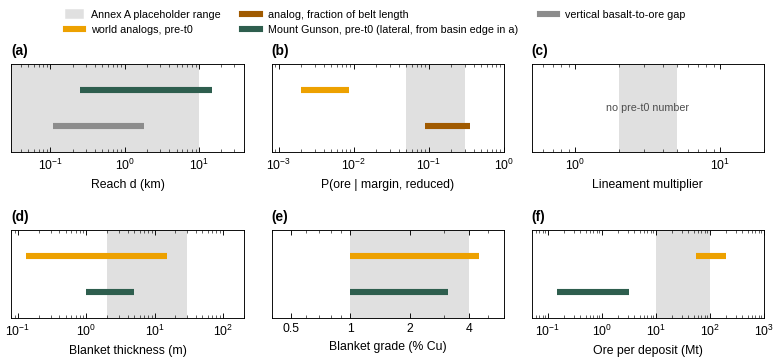

In [10]:
# Annex A Level 4 rows against what the level folder can cite
wa = x[TN.group == "world analog"]
rows = pd.DataFrame([
    ("reach d to a basalt margin", "0 to 10 km", "no lateral number before t0; Maiden 1974 Cu fall-off over 1-15 km is from the basin edge; "
     "vertical basalt-to-ore gaps 0.2 km (Gunson) and 0.11-1.85 km (White Pine)", "G20, G27, row 16", "bounds only; testimony"),
    ("P(ore | margin, reduced)", "0.05 to 0.3", f"area fractions {FR.lo.min():.3f}-{FR.hi.iloc[1]:.4f}; along-belt fractions "
     f"{FR.lo.iloc[2:].min():.2f}-{FR.hi.iloc[2:].max():.2f}", "L3 rows 1, 6, 7; row 30", "in state, analog; scale-dependent"),
    ("lineament-intersection multiplier", "2 to 5", "qualitative only: ore near faults (Mansfeld), coincidence of environments (PP 820); "
     "O'Driscoll 1974 targets carry no weight", "rows 19, 34", "no number; testimony"),
    ("blanket thickness", "2 to 30 m", f"ore beds {ore.lo.min():.2f}-{ore.hi.max():.0f} m; Gunson 1-5 m; Copperbelt < 15 m in most cases",
     "rows 1, 11, 27, 36; G4, G22, G26, G36", "in state; annex lower bound too high for shale-hosted analogs"),
    ("blanket grade", "1 to 4% Cu", f"Copperbelt 2-4.5 (mean 3.5); Mansfeld 2.5-2.8; White Pine 1-2.5; Gunson "
     f"{GU.grade.min():.1f}-{GU.grade.max():.1f}", "rows 8, 10, 32, 45, 46; G3-G36", "in state, supported"),
    ("blanket tonnage", "lognormal, median tens of Mt", f"median {10**mu:.1f} Mt, log10 sd {sd:.2f} over {len(x)} deposits; "
     f"world analogs {10**wa.min():.0f}-{10**wa.max():.0f} Mt, Gunson {GU.Mt.min():.2f}-{TN.Mt[TN.group=='Mount Gunson'].max():.1f} Mt",
     "rows 7, 8, 21, 31, 32; G3-G36", "in state; bimodal"),
], columns=["parameter", "annex_value", "in_state_value", "source", "status"])
rows.to_csv(TAB / "wp4_L4_parameter_rows.csv", index=False)
print(rows.to_string(index=False))

P = [("Reach d (km)", (0.03, 10), [(0.25, 15, GUNSON_COL, "lateral, from edge"), (0.11, 1.85, "0.55", "vertical gap")], (0.03, 40)),
     ("P(ore | margin, reduced)", (0.05, 0.3), [(FR.lo.min(), FR.hi.iloc[1], MEAS_COL["area"], "area"),
                                                (FR.lo.iloc[2:].min(), FR.hi.iloc[2:].max(), MEAS_COL["along the belt"], "belt")], (8e-4, 1)),
     ("Lineament multiplier", (2, 5), [], (0.5, 20)),
     ("Blanket thickness (m)", (2, 30), [(ore.lo.min(), ore.hi.max(), PIECE_COL[2], "analog ore beds"), (1, 5, GUNSON_COL, "Gunson")], (0.08, 200)),
     ("Blanket grade (% Cu)", (1, 4), [(1.0, 4.5, PIECE_COL[2], "analogs"), (GU.grade.min(), GU.grade.max(), GUNSON_COL, "Gunson")], (0.4, 6)),
     ("Ore per deposit (Mt)", (10, 100), [(10 ** wa.min(), 10 ** wa.max(), PIECE_COL[2], "world analogs"),
                                          (GU.Mt.min(), TN.Mt[TN.group == "Mount Gunson"].max(), GUNSON_COL, "Gunson")], (0.05, 1000))]
fig, axes = plt.subplots(2, 3, figsize=(COL2, 3.2))
fig.subplots_adjust(left=0.04, right=0.99, top=0.84, bottom=0.12, wspace=0.12, hspace=0.9)
for ax, (lab, band, bars, xl) in zip(axes.flat, P):
    ax.axvspan(*band, color=ANNEX_GREY, lw=0)
    for j, (lo, hi, c, _) in enumerate(bars):
        ax.plot([lo, hi], [j, j], color=c, lw=4, solid_capstyle="butt")
    if not bars:
        ax.text(np.sqrt(xl[0] * xl[1]), 0.5, "no pre-t0 number", ha="center", va="center", fontsize=FS_ANNOT, color="0.3")
    ax.set_xscale("log"); ax.set_xlim(*xl); ax.set_ylim(1.7, -0.7)
    ax.set_yticks([]); ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_xlabel(lab, fontsize=FS_ANNOT + 1)
    if "grade" in lab:
        ax.set_xticks([0.5, 1, 2, 4]); ax.set_xticklabels(["0.5", "1", "2", "4"]); ax.xaxis.set_minor_formatter(plt.NullFormatter())
panel_labels(axes.flat, ("(a)", "(b)", "(c)", "(d)", "(e)", "(f)"))
h = [plt.Rectangle((0, 0), 1, 1, color=ANNEX_GREY, label="Annex A placeholder range"),
     plt.Line2D([], [], color=PIECE_COL[2], lw=4, label="world analogs, pre-t0"),
     plt.Line2D([], [], color=MEAS_COL["along the belt"], lw=4, label="analog, fraction of belt length"),
     plt.Line2D([], [], color=GUNSON_COL, lw=4, label="Mount Gunson, pre-t0 (lateral, from basin edge in a)"),
     plt.Line2D([], [], color="0.55", lw=4, label="vertical basalt-to-ore gap")]
fig.legend(handles=h, loc="upper center", ncol=3, fontsize=FS_ANNOT, bbox_to_anchor=(0.5, 1.02))
fig.savefig(FIG / "wp4_L4_C1_parameters.png", dpi=300)
plt.show()


### How to read this figure

Each panel is one annex parameter on a logarithmic axis; the grey band is the annex placeholder and the bars are the ranges stated before t0. (a) Reach d: the only lateral length is Maiden's 0.25 to 15 km from the Gunson basin edge and shoreline (green); the grey bar is the vertical basalt-to-ore gap, 0.11 to 1.85 km, which is not a reach. (b) Occurrence probability: area fractions of 0.002 to 0.0086 fall far below the annex band, along-belt fractions of 0.09 to 0.35 fall on it. (c) Lineament multiplier: nothing written before t0 gives a number. (d) Thickness: analog ore beds 0.13 to 15 m and Gunson 1 to 5 m overlap only the lower part of 2 to 30 m. (e) Grade: analogs 1.0 to 4.5% and Gunson 1.0 to 3.1% sit on the annex 1 to 4%. (f) Ore per deposit: world analogs 57 to 198 Mt lie just above the band, Gunson 0.15 to 3.2 Mt far below it. Grade is confirmed; thickness and tonnage need rewriting; d and the multiplier stay testimony.


## What this shows

Level 4 splits cleanly along its two basis pieces. The blanket statistics (piece 2) can now be written from the pre-t0 record: grade 1 to 4.5% Cu as the annex has it; thickness about 0.5 to 15 m rather than 2 to 30 m; and tonnage as two families rather than one lognormal, a Gunson-scale family near 0.3 Mt and a world-analog family near 100 Mt, with the choice between them a modelling decision that should be stated, not hidden in a median. The rule itself (piece 1) has a pre-t0 author for its shape, Johns (1972) at Mount Gunson and PP 820 environment 10, but no pre-t0 number for its reach d or for the lineament multiplier, and its occurrence probability depends on whether the margin already confines the model to a belt (0.09 to 0.35) or not (0.002 to 0.009).

Open for the advisor: (1) request Haynes's memoranda from BHP, or carry d and the multiplier as testimony with the bounds above; (2) choose the tonnage family, or carry both as a mixture with an explicit weight; (3) whether the Pacminex 1975/76 genesis text, which names a basic dyke as the copper source, can enter once its circulation date is settled; (4) the USBM Minerals Yearbooks 1971 and 1972 for the Lubin figures, still not downloadable.
